In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.16'

file_019


(0.99, 1.015)

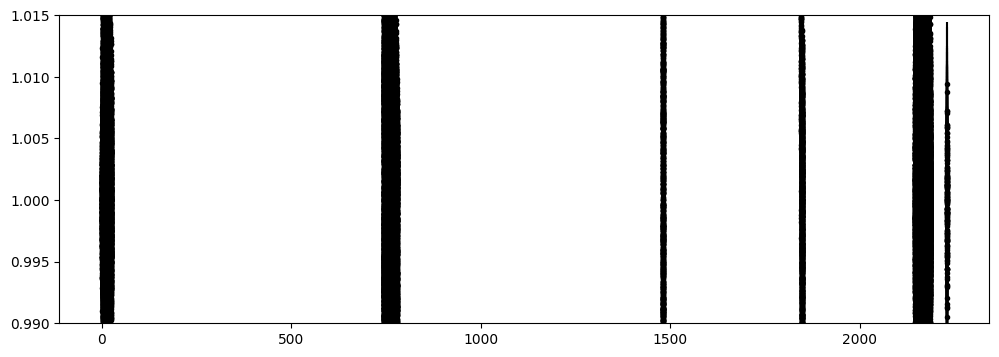

In [18]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
i = 0
file_to_use = all_files[i]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

use_pwv = 0

t = data["bjd"].values - data["bjd"].values[0]
if use_pwv and 'diff_flux_pwv' in data:
    f = data["diff_flux_pwv"].values
    used_pwv = 1
else:
    f = data['diff_flux'].values
ferr = data["diff_error"].values
fwhm = data['fwhm'].values
pwv = data['PWV'].values
seeing = data['seeing'].values
ramove = data['RA_move'].values
decmove = data['DEC_move'].values
alc = data['ALC'].values

# f = np.ones_like(t)
# sigma = 5e-3
# ferr = np.ones_like(t) * sigma
# f = f + np.random.normal(0, sigma, size=t.size)

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]
name = star_info['TARGET'].values[0]
print(name)

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [42]:
targ = LightCurve(name = name,
                  # time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  timelike={'time': t, 'fwhm':fwhm, 'pwv':pwv, 'seeing':seeing, 'ra_move':ramove,
                           'dec_move':decmove, 'artificial_lightcurve':alc},
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



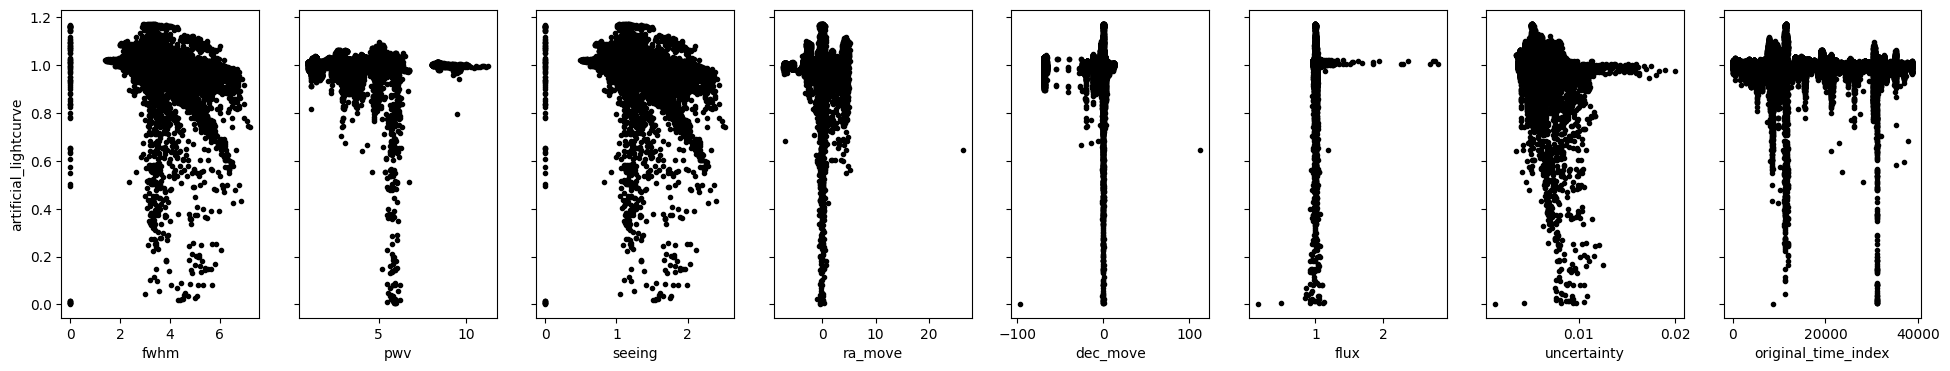

In [44]:
targ.plot_timelike_quantities('artificial_lightcurve')

Masking NaN fluxes...
Masking zero fluxes...
Masking bad weather...

            4.416436374906377% of data is flagged as bad weather ⛅.
            
Masking dust-crossing events...
Masking cosmic ray hits...

            0.22211317441049616% of data is flagged as cosmics ⚡.
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.96, 1.04)

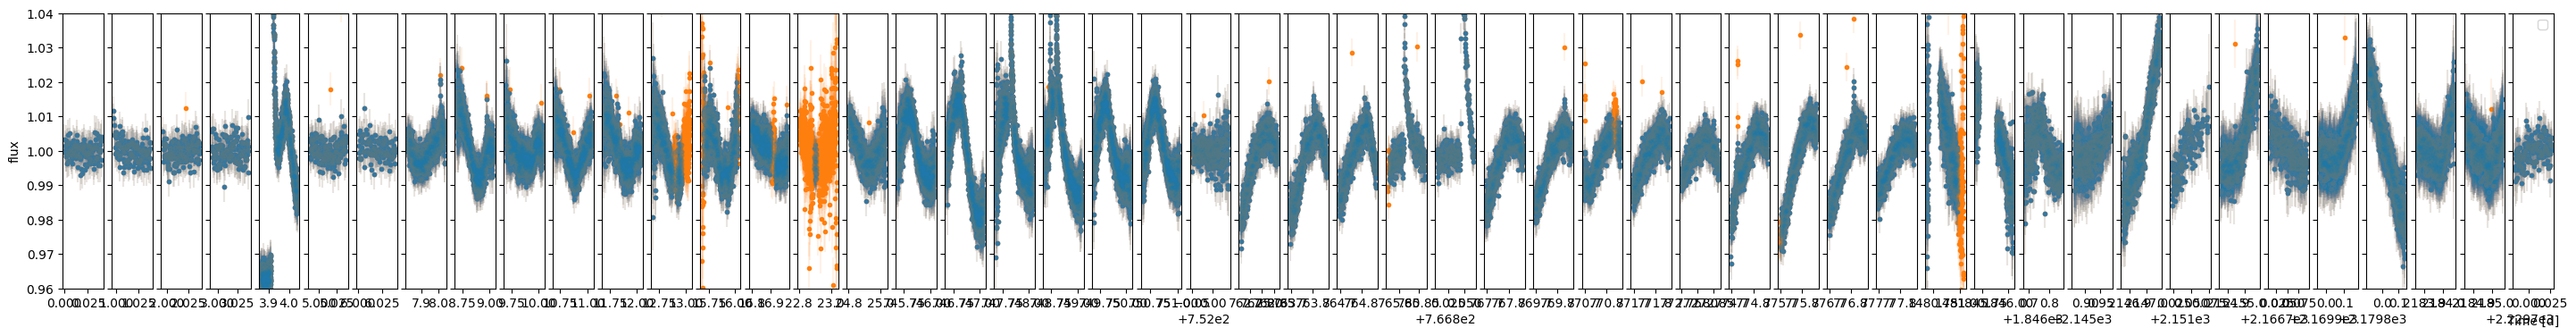

In [57]:
clean_targ = targ.clean(#thresholds={'fwhm':1.5}, threshold_operators={'fwhm':"<"}, 
                        bad_weather_removal=True,
                        verbose=True)
ax = targ.plot( color='C1')
clean_targ.plot(ax=ax, color='C0', ylims=[0.96,1.04])

plt.ylim(0.96,1.04)

In [52]:
# targ_with_transit = targ.clean().inject_transit(per=10*u.d, 
#                                         epoch=0.025 * u.d, 
#                                         inc=90 * u.degree, 
#                                         rp=2 * u.R_earth, 
#                                         ld=[0.3,0.3])

In [53]:
# targ.bin(dt=20*u.minute).time

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


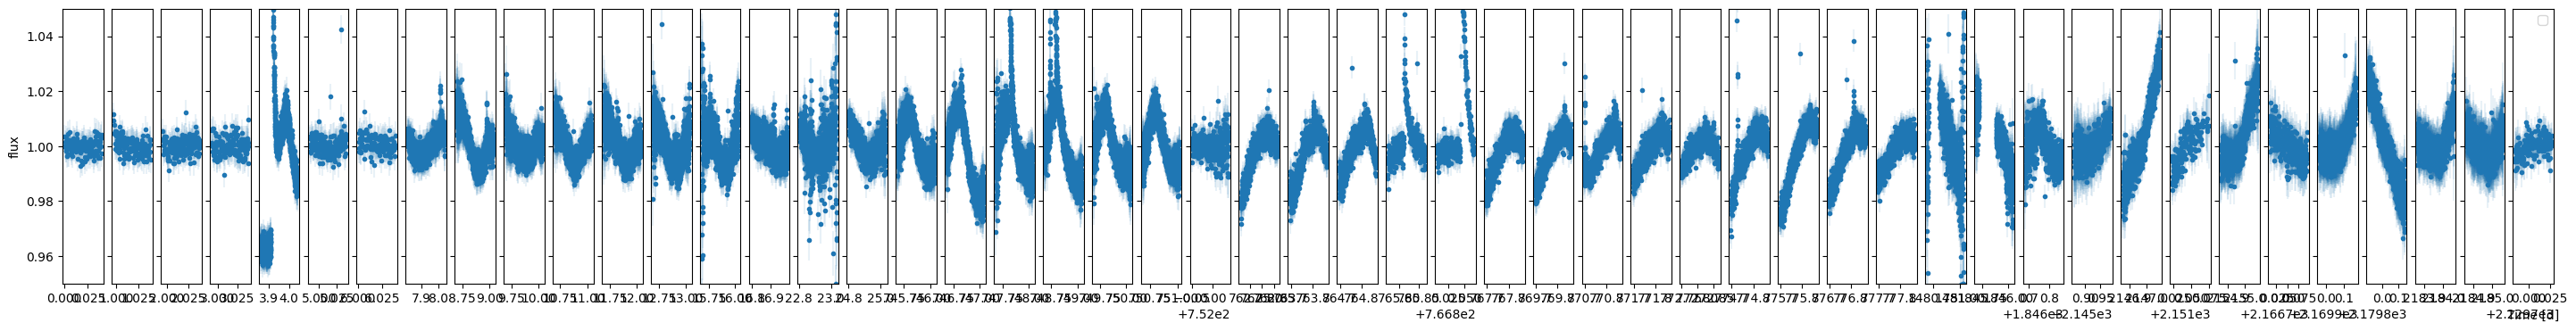

In [54]:
ax=targ.plot(ylims=[0.95,1.05])
# targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-",)

In [9]:
# a = targ.find_transits(transit_durations=[0.01,0.02,0.03,0.04],
#                             minimum_period=0.5, 
#                             maximum_period=30,
#                             oversample=10,
#                             obj="snr",
#                             minimum_n_transit=2,
#                            verbose=True, plot=True,
#                             nperiods=100000)

In [10]:
# per=2.55*u.d
# epoch=0.025 * u.d
# inc=90 * u.degree
# rp=1 * u.R_earth
# ld=[0.3,0.3]

# planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
#                                                           minimum_planet_radius=rp, 
#                                                           maximum_planet_radius=rp,
#                                                           minimum_period=per, 
#                                                           maximum_period=per,
#                                                         )
# planets

In [11]:
# lcs_with_transits, planets = targ.inject_lots_of_transits(nfake=10,
#                                                                   minimum_planet_radius=rp,
#                                                                   maximum_planet_radius=rp,
#                                                                   minimum_period=per,
#                                                                   maximum_period=10*u.d,
#                                                                   ld=ld,
#                                                           )

In [12]:
# lcs_with_transits

In [ ]:
bls_bin = (5 * u.minute)

x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=5,
                             minimum_planet_radius=0.5 * u.R_earth, 
                             maximum_planet_radius=6 * u.R_earth,
                             minimum_period=0.5 * u.d, 
                             maximum_period=20 * u.d, 
                             ld=[0.65,0.28],  # use trappist-1 (Gillon+16)
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':False},
                             flare_kw = {'plot':False, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': False, 'verbose':False,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":0.5, "maximum_period":30, 'minimum_n_transit':2, 'obj':'snr',
                                      'minpower':3,'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 
                                      'plot':False, 'verbose': False, 'nperiods':100000, 'oversample':10,}, 
                            bls_bin=bls_bin,
                            recovery_kw = {'condition_on_epoch':0.5 * u.hour, 
                                           'min_n_transits': 2, 
                                           # 'meet_condition': 'any',
                                          'verbose':False},                           
                            verbose=False, plot=False, time_this_process=True,
                           plot_dir='../../Results/', save_plots=False, save_lcs=False,
                           # plot_kw={'ylims':[0.98,1.02]},
                           svname=f"../../Results/{name}_injected_planets.csv",
                           min_save=True)

1/5...
Time to clean LC: 32.19180488586426


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 6 flare candidates with >30.0 s over 3$\sigma$
            
Time to remove flares: 98.00236010551453


Time to BLS before detrending: 11.912978887557983


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Time to detrend: 171.75640606880188
Time to BLS search: 13.73325514793396
2/5...
Planet was not observed, skipping...
3/5...


In [59]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [70]:
targ.name

'file_019'

In [71]:
# i=4
# ax=lcs[i].plot()
# lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
# try:
#     print(lcs_bls[i][0].metadata['BLS_transits_found'])
# except:
#     print(False)
#     pass
# planets_df = pd.read_csv(f"../../Results/{targ.name}_injected_planets.csv")
# planets_df

In [72]:
# planets_df['depth'], (((planets_df['r_p'].values*u.earthRad)/(0.1*u.solRad)).decompose())**2, planets_df['rec_depth']

In [73]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0      0.14 solRad
1      0.14 solRad
2      0.14 solRad
3      0.14 solRad
4      0.14 solRad
          ...     
995    0.14 solRad
996    0.14 solRad
997    0.14 solRad
998    0.14 solRad
999    0.14 solRad
Name: r_s, Length: 1000, dtype: object

In [74]:
# period = 10**planets_df['logP']

# duration = 

# lcs_bls

Text(0.5, 0, 'Planet Radius [R_earth]')

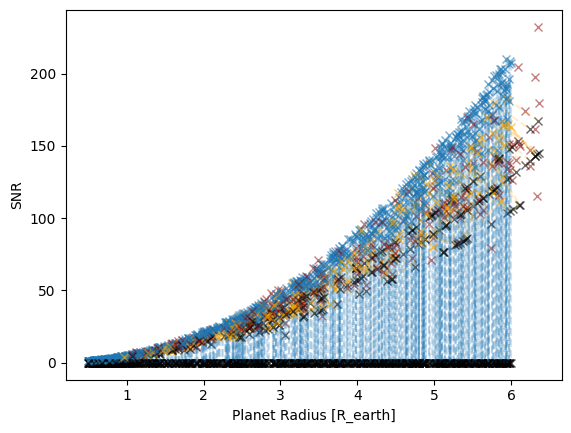

In [75]:
from astropy.units import Quantity

bls_bin = (5 * u.minute)
n_points_in_transit = planets_df['duration']/(bls_bin.to_value('day'))
lc_noise = np.nanmedian(targ.uncertainty) #1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for i,(r_p, rr_depth, dur, rec_depth, rec_dur, rec, obs, r_p_rec, snr, n) in enumerate(zip(planets_df['r_p'],
                                                            planets_df['depth'],
                                                            planets_df['duration'],
                                                          planets_df['rec_depth'],
                                                        planets_df['rec_duration'],
                                                          planets_df['recovered'],
                                                          planets_df['observed'],
                                                          rec_r_p,  planets_df['snr'], 
                                                          n_points_in_transit)):
    if i == 0:
        labeli="injected"
        labelr="recovered"
        labelnr="not recovered"
        labelo="observed"
    else:
        labeli, labelr, labelnr, labelo = None, None, None,None
        
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
        
    if r_p_rec == 0.0:
        r_p_rec = r_p
        # snr = 0 #rr_depth * dur/lc_noise

    n_rec = rec_dur/(bls_bin.to_value('day'))

    derived_snr = rr_depth * np.sqrt(n)/lc_noise #np.sqrt(n)/lc_noise
    rec_snr = rec_depth * np.sqrt(n_rec) / lc_noise
    # derived_snr_theory = rr_depth * rec_dur / lc_noise
    plt.plot([r_p], [derived_snr], 'x', color=color, alpha=0.6,label="Derived SNR")
    plt.plot([r_p_rec], [rec_snr], 'x', color='k', alpha=0.6,label="Recovered SNR")
    # plt.plot([r_p], [derived_snr2], 'x', color=color, alpha=0.6,label=labeli)
    plt.plot([r_p,r_p_rec], [derived_snr, rec_snr], '--', color=color, alpha=0.2)

    # print(f"""
    # Rp/R* depth = {rr_depth:.3f},
    # Recovered depth = {rec_depth:.3f},
    # Theoretical duration = {dur:.3f},
    # Recovered duration = {rec_dur:.3f},
    # Number of points in transit = {n:.0f},
    # lc noise = {lc_noise}
    # """)

    # if obs == 1.0:
    #     plt.plot([r_p], [derived_snr], 'o', color=color, alpha=0.6, label=labelo)
    
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5, label=labelr)
    
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")
# plt.legend()

Fraction of injections observed: 0.541


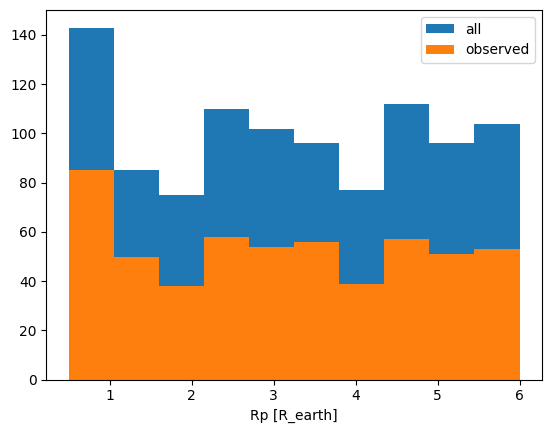

In [76]:
plt.hist(planets_df['r_p'], label='all')
plt.hist(planets_df['r_p'][planets_df['observed'] == 1.0], label='observed')
plt.xlabel("Rp [R_earth]")
plt.legend()

print(f"Fraction of injections observed: {len(planets_df['r_p'][planets_df['observed'] == 1.0])/len(planets_df['r_p'])}")

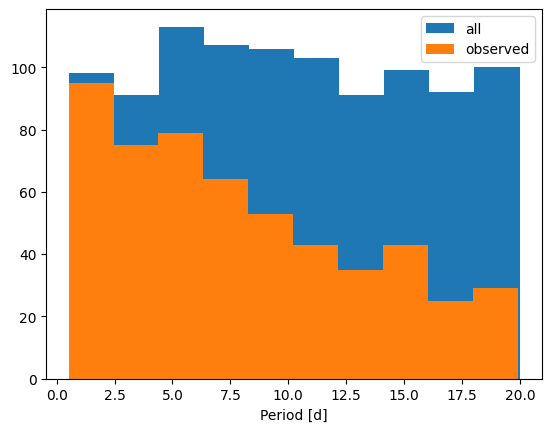

In [77]:
plt.hist(10**planets_df['logP'],label="all")
plt.hist(10**planets_df['logP'][planets_df['observed'] == 1.0], label="observed")
plt.xlabel("Period [d]")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


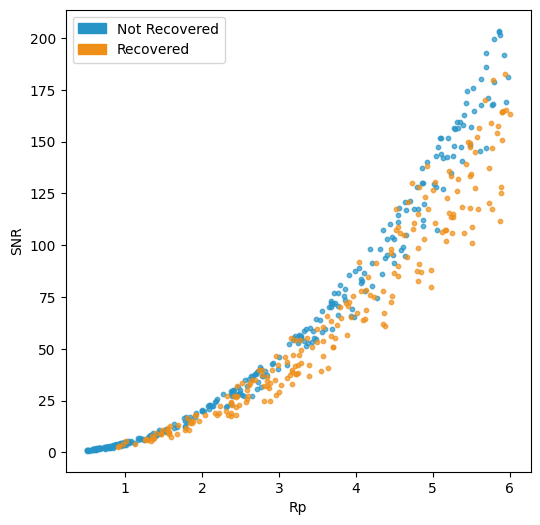

In [78]:
x = planets_df['r_p'][planets_df['observed'] == 1.0]
plot_transitparams(x=x, 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Rp", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=10,)
                   # svname=f"../../Results/{name}_injected_snr_Rp.png")

# plt.plot(sorted(x), (np.array(sorted(x))**2) * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0]) /lc_noise)

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/occultence/recovery/plots.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  error_in_frac = (1 / N) * np.sqrt(n_success * (1 + (n_success / N)))


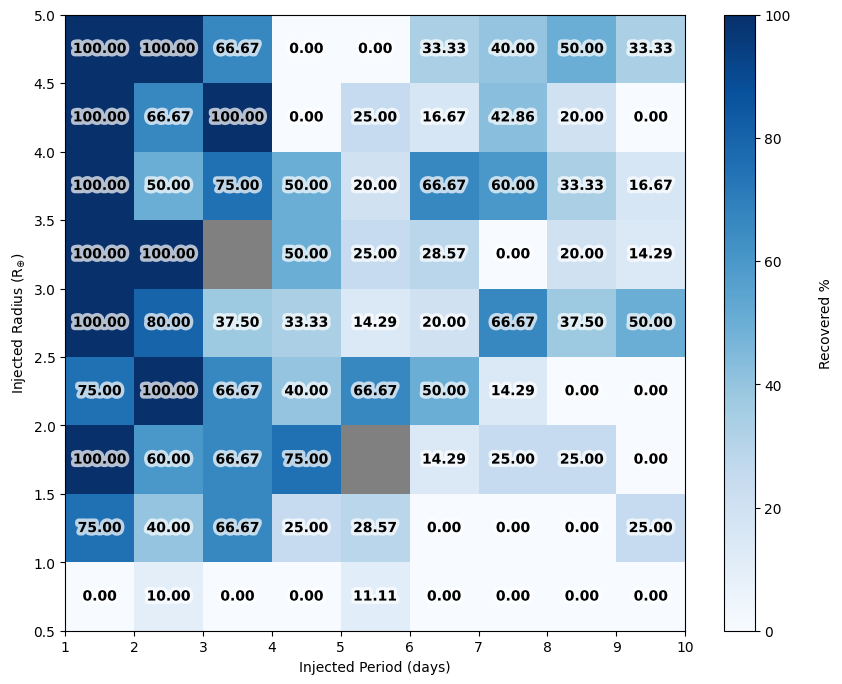

In [79]:
P_bins = np.linspace(1,10,10)
R_bins = np.linspace(0.5,5,10)

twod_plot(x=10**planets_df['logP'],
          y=planets_df['r_p'],
          z=planets_df['recovered'],
          x_bins=P_bins,
          y_bins=R_bins,
          zlabel="Recovered %",
          statistic="mean",
          addtext=True,)
          # svname=f"../../Results/{name}_recovered.png")

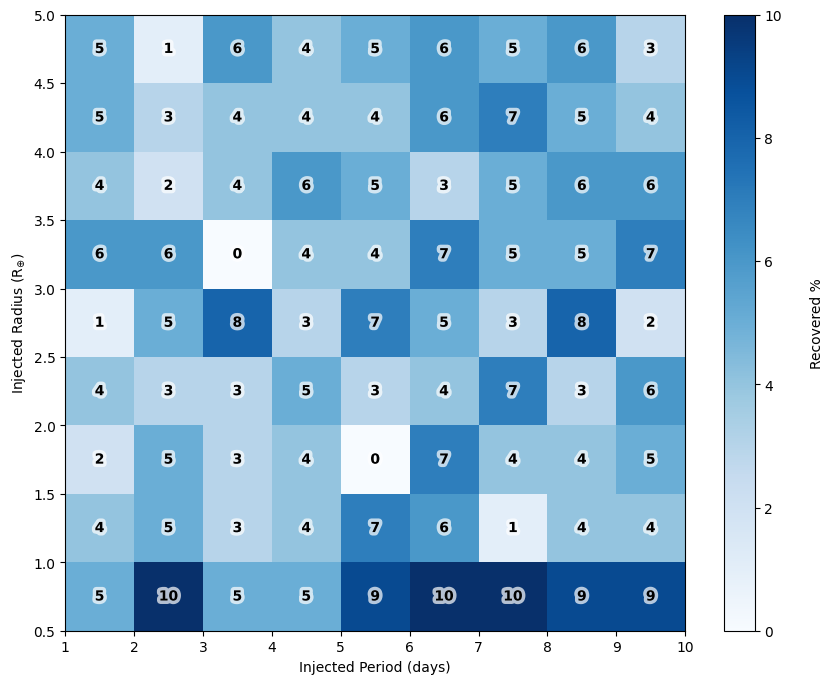

In [80]:
twod_plot(x=10**planets_df['logP'],
          y=planets_df['r_p'],
          z=planets_df['recovered'],
          x_bins=P_bins,
          y_bins=R_bins,
          zlabel="Recovered %",
          statistic="count",
          nsig="%0.0f",
          addtext=True,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


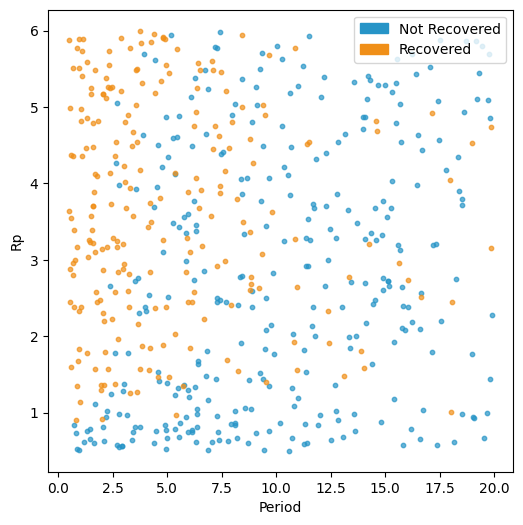

In [81]:
plot_transitparams(x=10**planets_df['logP'][planets_df['observed'] == 1.0], 
                   y=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="Rp", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=10,)